In [ ]:
#@title Install Dependencies
%%capture

!pip uninstall -y tensorflow tensorflow-text tf-keras keras tensorboard numpy ml-dtypes protobuf jax jaxlib numba tensorflow-cpu

!pip install -q \
  "tensorflow==2.20.0" \
  "protobuf>=5.29.1,<6"

!pip install -q \
  "numpy>=2.0.2,<2.6" \
  "ml-dtypes>=0.5.0" \
  "tf-keras>=2.20.0" \
  "tensorflow-text==2.20.0" \
  "jax==0.7.2" \
  "jaxlib==0.7.2" \
  "tpu-info"


# Targeted Masking ColabFold Notebook

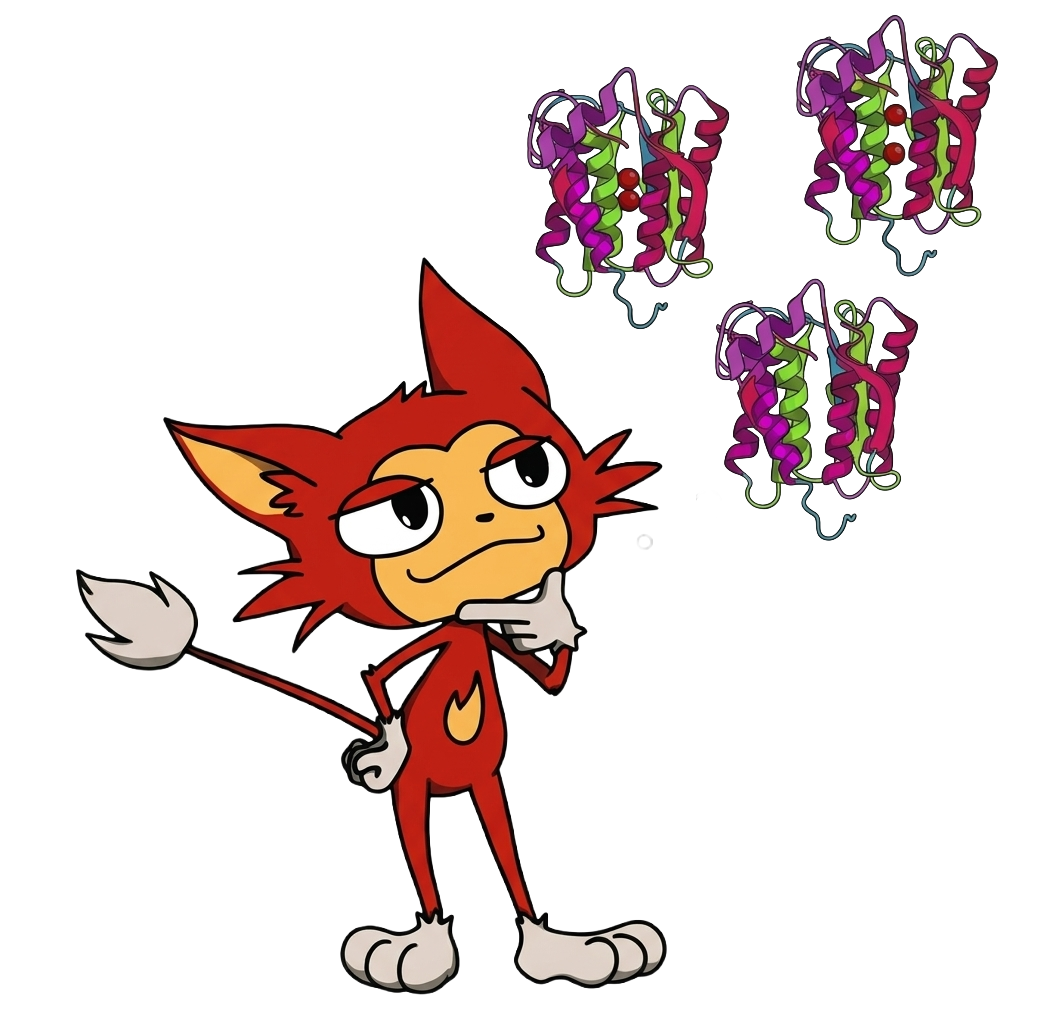

[![Open the latest Targeted Masking notebook in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adrishg/targetedMasking/blob/main/targetedMasking_AF2_v1_Cav12_vsd2Test.ipynb)

**Targeted MSA masking extension** for ColabFold/AlphaFold2 workflows.

Developed by **Adriana Hernandez Gonzalez**, PhD candidate, **Yarov-Yarovoy Lab**, **UC Davis**.

This notebook keeps the original ColabFold workflow and adds an optional targeted MSA masking step before prediction. The default example sequence corresponds to a VSD2-like segment from the CaV1.2 voltage-gated calcium channel.

The masking idea is to preserve the query sequence while selectively masking columns in the homologous MSA sequences. This can help explore whether AlphaFold2 is being strongly constrained by evolutionary information in specific regions. Two masking modes are included:

- **Targeted/stochastic masking**: mask a chosen fraction of positions in regions expected to vary or move in ion-channel proteins, adding variability to the information available to the model.
- **Mutant/full masking**: fully mask selected mutation sites to reduce or remove MSA-derived constraints at those positions.

A future placeholder is also included for voltage-gated-channel/VSD-aware automatic masking suggestions, but in this v5 notebook the actual site selection is still manual.

> Original ColabFold code is MIT licensed; AlphaFold2 code/parameters remain under their original DeepMind licenses. This notebook adds a research-use targeted masking layer on top of the standard ColabFold workflow.


In [ ]:
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'RISKSKFSRYWRRWNRFCRRKCRAAVKSNVFYWLVIFLVFLNTLTIASEHYNQPNWLTEVQDTANKALLALFTAEMLLKMYSLGLQAYFVSLFNRFDCFVVCGGILETILVETKIMSPLGISVLRCVRLLRIFKITRYW' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'CaV1_2_VSD2_targeted_masking' #@param {type:"string"}
# number of models to use
num_relax = 0 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname CaV1_2_VSD2_targeted_masking_7e380_0
sequence RISKSKFSRYWRRWNRFCRRKCRAAVKSNVFYWLVIFLVFLNTLTIASEHYNQPNWLTEVQDTANKALLALFTAEMLLKMYSLGLQAYFVSLFNRFDCFVVCGGILETILVETKIMSPLGISVLRCVRLLRIFKITRYW
length 139


In [ ]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

CPU times: user 24 µs, sys: 0 ns, total: 24 µs
Wall time: 27.9 µs


In [ ]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

## Optional targeted MSA masking

Run the notebook normally up through the MSA/options cells. The prediction cell can run the **vanilla** ColabFold prediction first, then create a masked A3M, then run a **targeted-masked** prediction using that masked A3M.

For a clean first pass:
1. Leave **run_vanilla_first = True**.
2. Add positions in **mutant_ranges** and/or **targeted_masking_positions**.
3. Leave **run_targeted_masked_prediction = True** if you want the masked prediction after vanilla.
4. Leave the automatic VSD suggestion checkbox off for now; it is only a placeholder in v5.


In [ ]:
#@title Targeted masking controls + masked-site preview
#@markdown This cell prepares the targeted masking settings and previews the selected positions.
#@markdown - In a normal **Run all** workflow, the A3M may not exist yet. That is OK: the prediction cell can run vanilla first, then create the masked A3M automatically.
#@markdown - **mutant_ranges**: deterministic full masking, e.g. `3-10,45,80-90`. This is useful for mutation sites where you want to reduce MSA-derived constraints.
#@markdown - **targeted_masking_positions**: stochastic/percentage-based masking, e.g. `20-60`. This is useful for regions expected to vary or flex, such as channel/VSD regions.
#@markdown - **targeted_mask_percent**: fraction of selected targeted positions to mask in each homologous sequence.

masking_action = "prepare_masked_msa" #@param ["skip", "prepare_masked_msa"]
masking_char = "X" #@param ["X", "-"] {type:"string"}
mutant_ranges = "" #@param {type:"string"}
targeted_masking_positions = "15,19,22,23,26,28,31,32,38,42,45,49, 59,62,65,72,73,75,76,78,79,81,82,88,94,97,98,102,107,112,122,125,128,131,134,137" #@param {type:"string"}
targeted_mask_percent = 1.0 #@param {type:"number"}
mask_chain = "A" #@param {type:"string"}
random_seed_for_masking = 7 #@param {type:"integer"}

#@markdown ---
#@markdown ### Future voltage-gated-channel / VSD-aware masking helper
voltage_gated_channel_mode = False #@param {type:"boolean"}
auto_suggest_targeted_masking = False #@param {type:"boolean"}
#@markdown Placeholder only for now. Later this can suggest masking sites from VSD-like sequence patterns,
#@markdown such as repeated basic gating-charge residues and nearby flexible/interacting loops.

import os, random, html
from IPython.display import display, HTML

def parse_ranges_for_preview(spec):
  out = set()
  for part in str(spec).split(','):
    part = part.strip()
    if not part:
      continue
    if '-' in part:
      a, b = part.split('-', 1)
      a, b = int(a), int(b)
      if a > b:
        a, b = b, a
      out.update(range(a, b + 1))
    else:
      out.add(int(part))
  return sorted(out)

def has_requested_targeted_masking():
  return bool(str(mutant_ranges).strip() or str(targeted_masking_positions).strip())

def read_a3m_records(path):
  records, header, chunks = [], None, []
  with open(path) as f:
    for line in f:
      line = line.rstrip()
      if not line:
        continue
      if line.startswith('>'):
        if header is not None:
          records.append((header, ''.join(chunks)))
        header, chunks = line, []
      else:
        chunks.append(line)
  if header is not None:
    records.append((header, ''.join(chunks)))
  if not records:
    raise ValueError(f'No sequences found in {path}')
  return records

def write_a3m_records(records, path):
  with open(path, 'w') as f:
    for h, s in records:
      f.write(h + '\n')
      for i in range(0, len(s), 120):
        f.write(s[i:i+120] + '\n')

def query_position_to_alignment_columns(query_seq, start=0, end=None):
  if end is None:
    end = len(query_seq)
  qmap = {}
  qpos = 0
  for i in range(start, end):
    ch = query_seq[i]
    if 'A' <= ch <= 'Z':
      qpos += 1
      qmap.setdefault(qpos, []).append(i)
  return qmap

def chain_offsets_from_query_sequence(seq_with_colons):
  parts = seq_with_colons.split(':')
  offsets = []
  s = 0
  for p in parts:
    offsets.append((s, s + len(p)))
    s += len(p)
  return parts, offsets

def make_masked_a3m(input_a3m, output_a3m, query_sequence_for_chains, mutant_spec, targeted_spec, targeted_fraction, masking_char='X', mask_chain='A', seed=7):
  random.seed(seed)
  records = read_a3m_records(input_a3m)
  query_header, query_seq = records[0]
  mutant_qpos = parse_ranges_for_preview(mutant_spec) if mutant_spec else []
  targeted_qpos = parse_ranges_for_preview(targeted_spec) if targeted_spec else []

  if not (0.0 <= float(targeted_fraction) <= 1.0):
    raise ValueError('targeted_mask_percent must be between 0 and 1')
  if len(masking_char) != 1:
    raise ValueError('masking_char must be a single character')

  is_multimer_query = ':' in query_sequence_for_chains
  if is_multimer_query:
    parts, offsets = chain_offsets_from_query_sequence(query_sequence_for_chains)
    chain_letter = mask_chain.strip().upper() or 'A'
    chain_index = ord(chain_letter) - ord('A')
    if chain_index < 0 or chain_index >= len(offsets):
      raise ValueError(f'mask_chain={mask_chain} is outside the available chains: {len(offsets)}')
    start, end = offsets[chain_index]
    qmap = query_position_to_alignment_columns(query_seq, start, end)
    chain_note = f'chain {chain_letter}, chain-local query numbering'
  else:
    chain_letter = 'A'
    qmap = query_position_to_alignment_columns(query_seq)
    chain_note = 'monomer/global query numbering'

  requested = sorted(set(mutant_qpos + targeted_qpos))
  applied = [p for p in requested if p in qmap]
  missing = [p for p in requested if p not in qmap]

  mutant_cols = sorted(set(c for p in mutant_qpos if p in qmap for c in qmap[p]))
  targeted_cols = sorted(set(c for p in targeted_qpos if p in qmap for c in qmap[p]))

  def maybe_mask(ch):
    return masking_char if 'A' <= ch <= 'Z' else ch

  new_records = []
  for idx, (hdr, seq) in enumerate(records):
    if idx == 0:
      new_records.append((hdr, seq))
      continue
    s = list(seq)
    for col in mutant_cols:
      if col < len(s):
        s[col] = maybe_mask(s[col])
    for col in targeted_cols:
      if col < len(s) and random.random() < float(targeted_fraction):
        s[col] = maybe_mask(s[col])
    new_records.append((hdr, ''.join(s)))

  write_a3m_records(new_records, output_a3m)
  return {
      'input_a3m': input_a3m,
      'output_a3m': output_a3m,
      'query_header': query_header,
      'n_records': len(records),
      'mutant_positions': mutant_qpos,
      'targeted_positions': targeted_qpos,
      'applied_positions': applied,
      'missing_positions': missing,
      'chain_note': chain_note,
      'mask_chain': chain_letter,
  }

def show_mask_preview(seq, mutant_positions, targeted_positions):
  clean = seq.replace(':','')
  mutant = set(mutant_positions)
  targeted = set(targeted_positions)
  chunks = []
  for i, aa in enumerate(clean, start=1):
    style = 'display:inline-block; min-width:1.35em; text-align:center; margin:1px; padding:2px; border-radius:4px; font-family:monospace;'
    title = f'position {i}: {aa}'
    if i in mutant and i in targeted:
      style += 'background:#6d28d9; color:white; font-weight:700;'
      title += ' | mutant + targeted mask'
    elif i in mutant:
      style += 'background:#dc2626; color:white; font-weight:700;'
      title += ' | mutant/full mask'
    elif i in targeted:
      style += 'background:#2563eb; color:white; font-weight:700;'
      title += ' | targeted/stochastic mask'
    else:
      style += 'background:#f3f4f6; color:#111827;'
    chunks.append(f'<span title="{html.escape(title)}" style="{style}">{html.escape(aa)}</span>')
  legend = """
  <div style="margin-bottom:0.6em; font-family:Arial;">
    <b>Targeted masking preview</b><br>
    <span style="background:#dc2626;color:white;padding:2px 6px;border-radius:4px;">mutant/full mask</span>
    <span style="background:#2563eb;color:white;padding:2px 6px;border-radius:4px;">targeted/stochastic mask</span>
    <span style="background:#6d28d9;color:white;padding:2px 6px;border-radius:4px;">overlap</span>
  </div>
  """
  display(HTML(legend + '<div style="line-height:2.1; max-width:100%;">' + ''.join(chunks) + '</div>'))

def prepare_masked_a3m_if_possible():
  global masked_a3m_file, masking_report
  masked_a3m_file = os.path.join(jobname, f'{jobname}.targeted_masked.a3m')
  if masking_action != 'prepare_masked_msa':
    masking_report = None
    print('Targeted masking skipped. Use masking_action = "prepare_masked_msa" when you are ready to create the masked A3M.')
    return None
  if not has_requested_targeted_masking():
    masking_report = None
    print('No targeted masking positions were provided. Add mutant_ranges and/or targeted_masking_positions to create a masked A3M.')
    return None
  if not os.path.isfile(a3m_file):
    masking_report = None
    print(f'A3M not found yet: {a3m_file}')
    print('This is expected before the first vanilla prediction in MMseqs2 mode.')
    print('The Run Prediction cell can run vanilla first, then create the masked A3M automatically.')
    return None
  masking_report = make_masked_a3m(
      input_a3m=a3m_file,
      output_a3m=masked_a3m_file,
      query_sequence_for_chains=query_sequence,
      mutant_spec=mutant_ranges,
      targeted_spec=targeted_masking_positions,
      targeted_fraction=targeted_mask_percent,
      masking_char=masking_char,
      mask_chain=mask_chain,
      seed=random_seed_for_masking,
  )
  print('Targeted-masked A3M ready:', masked_a3m_file)
  print('Input A3M:', masking_report['input_a3m'])
  print('Records:', masking_report['n_records'])
  print('Numbering:', masking_report['chain_note'])
  print('Applied positions:', masking_report['applied_positions'])
  if masking_report['missing_positions']:
    print('WARNING missing/ignored positions:', masking_report['missing_positions'])
  return masking_report

masked_a3m_file = os.path.join(jobname, f'{jobname}.targeted_masked.a3m')
masking_report = None

if auto_suggest_targeted_masking:
  print('Automatic voltage-gated-channel/VSD targeted masking suggestion is a placeholder in this version.')
  print('For now, manually set targeted_masking_positions or mutant_ranges. Later this can detect gating-charge-like basic residues and nearby loop regions.')

# Always show the requested sites on the query sequence so you can verify positions before running.
show_mask_preview(
    query_sequence,
    parse_ranges_for_preview(mutant_ranges) if mutant_ranges else [],
    parse_ranges_for_preview(targeted_masking_positions) if targeted_masking_positions else [],
)

prepare_masked_a3m_if_possible()


A3M not found yet: CaV1_2_VSD2_targeted_masking_7e380_0/CaV1_2_VSD2_targeted_masking_7e380_0.a3m
This is expected before the first vanilla prediction in MMseqs2 mode.
The Run Prediction cell can run vanilla first, then create the masked A3M automatically.


In [ ]:
#@markdown ### Advanced settings
model_type = "auto" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1", "alphafold2"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "3" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 200 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
#@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.
calc_extra_ptm = False #@param {type:"boolean"}
#@markdown - return pairwise chain iptm/actifptm

#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 1 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = False #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)
  print("You are logged into Google Drive and are good to go!")

#@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.

\n================================================================================
Running vanilla prediction
queries/MSA input: CaV1_2_VSD2_targeted_masking_7e380_0/CaV1_2_VSD2_targeted_masking_7e380_0.csv
msa_mode: mmseqs2_uniref_env


ERROR: libtpu not found.
2026-05-01 21:16:30,855 Running on GPU
2026-05-01 21:16:31,380 Found 5 citations for tools or databases
2026-05-01 21:16:31,381 Query 1/1: CaV1_2_VSD2_targeted_masking_7e380_0 (length 139)


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:01 remaining: 00:00]


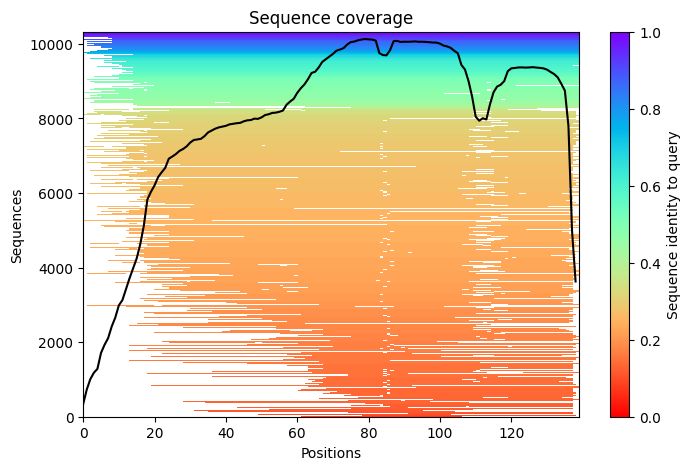

2026-05-01 21:16:35,313 Setting max_seq=512, max_extra_seq=5120
2026-05-01 21:17:33,429 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=78.8 pTM=0.695
2026-05-01 21:18:04,222 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=78.4 pTM=0.694 tol=0.585
2026-05-01 21:18:13,850 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=79.4 pTM=0.699 tol=0.273
2026-05-01 21:18:23,628 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=79.8 pTM=0.706 tol=0.0891
2026-05-01 21:18:23,629 alphafold2_ptm_model_1_seed_000 took 85.6s (3 recycles)


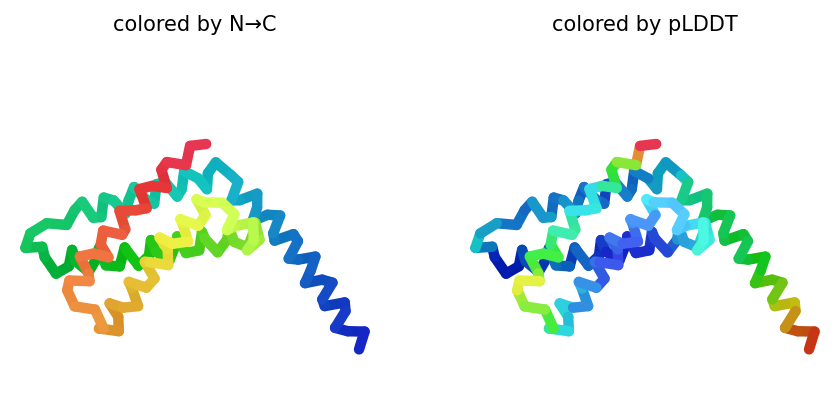

2026-05-01 21:18:33,748 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=70.9 pTM=0.59
2026-05-01 21:18:43,817 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=68.7 pTM=0.582 tol=0.599
2026-05-01 21:18:54,116 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=67.1 pTM=0.576 tol=0.389
2026-05-01 21:19:04,575 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=66.1 pTM=0.57 tol=0.317
2026-05-01 21:19:04,576 alphafold2_ptm_model_2_seed_000 took 40.8s (3 recycles)


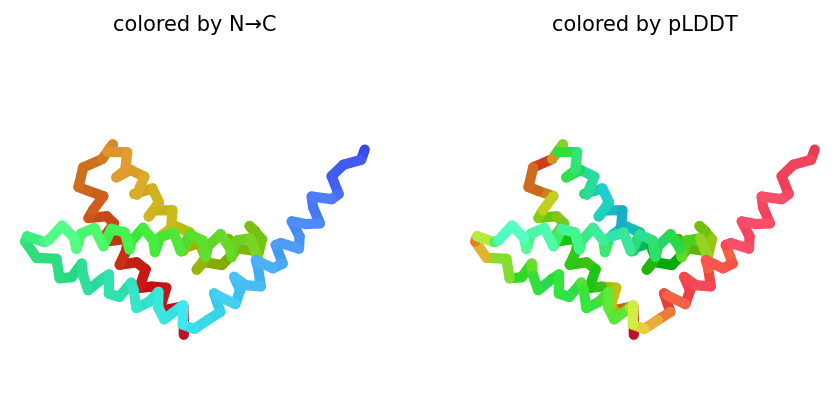

2026-05-01 21:19:15,399 alphafold2_ptm_model_3_seed_000 recycle=0 pLDDT=83.6 pTM=0.728
2026-05-01 21:19:26,191 alphafold2_ptm_model_3_seed_000 recycle=1 pLDDT=83.1 pTM=0.721 tol=0.309
2026-05-01 21:19:36,761 alphafold2_ptm_model_3_seed_000 recycle=2 pLDDT=82.9 pTM=0.722 tol=0.152
2026-05-01 21:19:47,148 alphafold2_ptm_model_3_seed_000 recycle=3 pLDDT=83.3 pTM=0.732 tol=0.0947
2026-05-01 21:19:47,149 alphafold2_ptm_model_3_seed_000 took 42.5s (3 recycles)


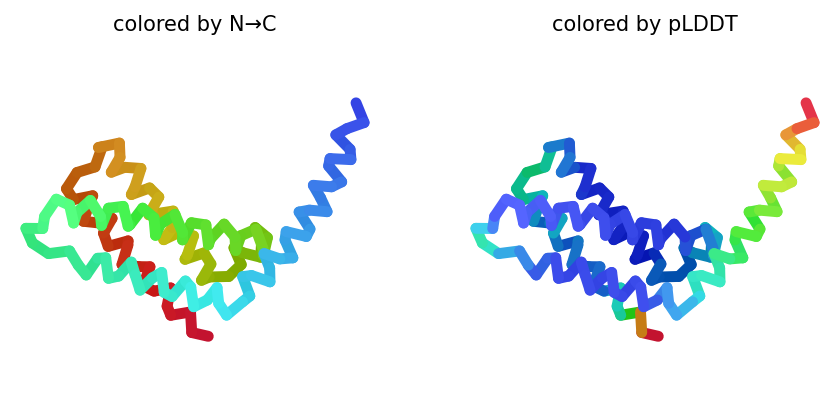

2026-05-01 21:19:57,615 alphafold2_ptm_model_4_seed_000 recycle=0 pLDDT=75.4 pTM=0.642
2026-05-01 21:20:07,965 alphafold2_ptm_model_4_seed_000 recycle=1 pLDDT=73.5 pTM=0.62 tol=1.1
2026-05-01 21:20:18,357 alphafold2_ptm_model_4_seed_000 recycle=2 pLDDT=74.2 pTM=0.629 tol=0.534
2026-05-01 21:20:28,804 alphafold2_ptm_model_4_seed_000 recycle=3 pLDDT=74 pTM=0.634 tol=0.362
2026-05-01 21:20:28,805 alphafold2_ptm_model_4_seed_000 took 41.6s (3 recycles)


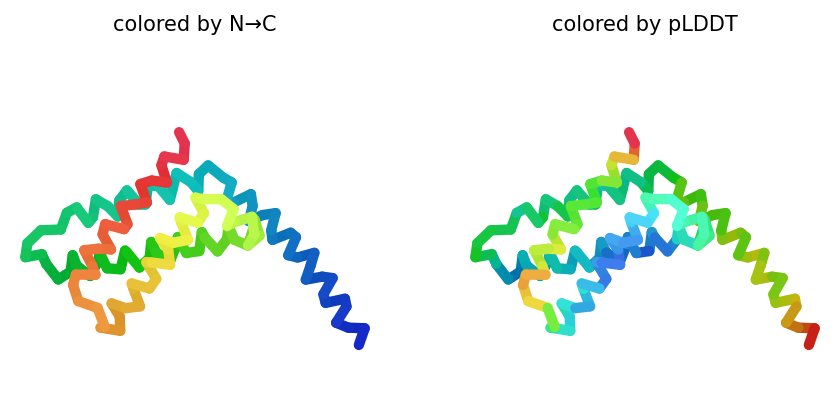

2026-05-01 21:20:39,491 alphafold2_ptm_model_5_seed_000 recycle=0 pLDDT=82.2 pTM=0.75
2026-05-01 21:20:50,090 alphafold2_ptm_model_5_seed_000 recycle=1 pLDDT=82.6 pTM=0.757 tol=0.311
2026-05-01 21:21:00,721 alphafold2_ptm_model_5_seed_000 recycle=2 pLDDT=82.7 pTM=0.764 tol=0.2
2026-05-01 21:21:11,115 alphafold2_ptm_model_5_seed_000 recycle=3 pLDDT=81.9 pTM=0.765 tol=0.279
2026-05-01 21:21:11,116 alphafold2_ptm_model_5_seed_000 took 42.2s (3 recycles)


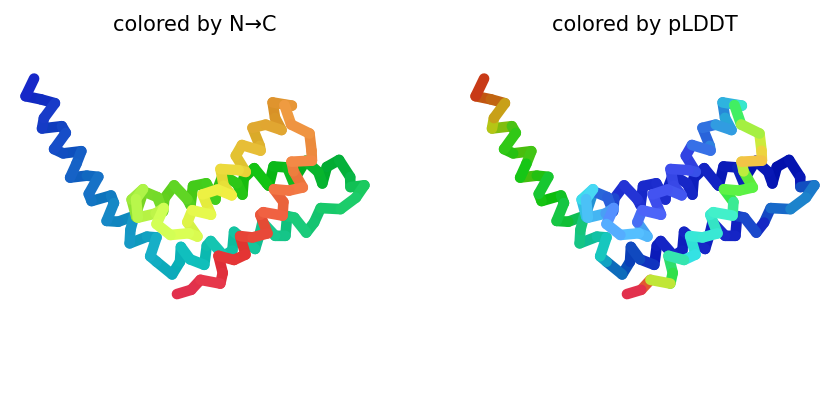

2026-05-01 21:21:11,225 reranking models by 'plddt' metric
2026-05-01 21:21:11,226 rank_001_alphafold2_ptm_model_3_seed_000 pLDDT=83.3 pTM=0.732
2026-05-01 21:21:11,226 rank_002_alphafold2_ptm_model_5_seed_000 pLDDT=81.9 pTM=0.765
2026-05-01 21:21:11,227 rank_003_alphafold2_ptm_model_1_seed_000 pLDDT=79.8 pTM=0.706
2026-05-01 21:21:11,227 rank_004_alphafold2_ptm_model_4_seed_000 pLDDT=74 pTM=0.634
2026-05-01 21:21:11,227 rank_005_alphafold2_ptm_model_2_seed_000 pLDDT=66.1 pTM=0.57
2026-05-01 21:21:12,380 Done
Targeted-masked A3M ready: CaV1_2_VSD2_targeted_masking_7e380_0/CaV1_2_VSD2_targeted_masking_7e380_0.targeted_masked.a3m
Input A3M: CaV1_2_VSD2_targeted_masking_7e380_0/CaV1_2_VSD2_targeted_masking_7e380_0.a3m
Records: 10325
Numbering: monomer/global query numbering
Applied positions: [15, 19, 22, 23, 26, 28, 31, 32, 38, 42, 45, 49, 59, 62, 65, 72, 73, 75, 76, 78, 79, 81, 82, 88, 94, 97, 98, 102, 107, 112, 122, 125, 128, 131, 134, 137]
\n===========================================

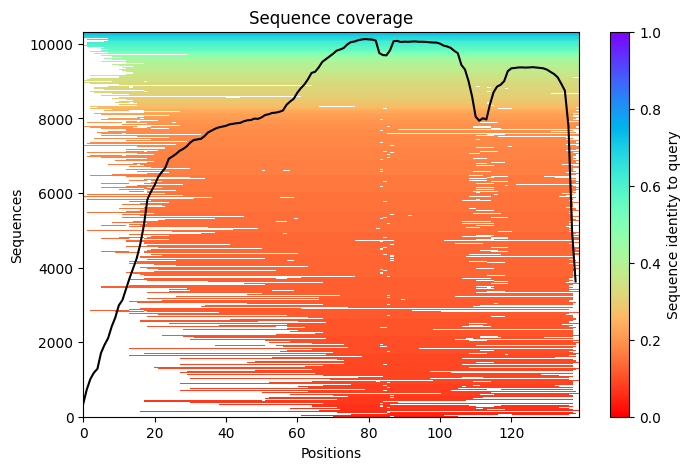

2026-05-01 21:21:14,084 Setting max_seq=512, max_extra_seq=5120
2026-05-01 21:21:53,244 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=77.9 pTM=0.643
2026-05-01 21:22:25,068 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=76.4 pTM=0.639 tol=0.192
2026-05-01 21:22:36,006 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=75.6 pTM=0.632 tol=0.17
2026-05-01 21:22:46,873 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=75.9 pTM=0.639 tol=0.152
2026-05-01 21:22:46,874 alphafold2_ptm_model_1_seed_000 took 83.0s (3 recycles)


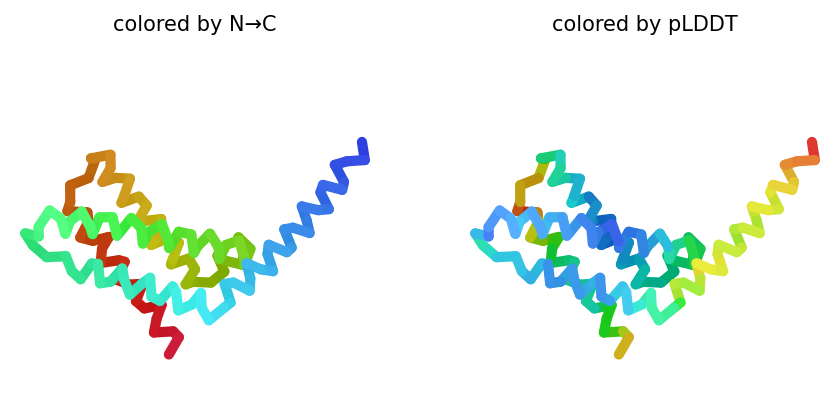

2026-05-01 21:22:57,547 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=76.8 pTM=0.657
2026-05-01 21:23:07,917 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=76 pTM=0.652 tol=0.186
2026-05-01 21:23:18,268 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=75.9 pTM=0.658 tol=0.131
2026-05-01 21:23:28,622 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=76 pTM=0.661 tol=0.122
2026-05-01 21:23:28,623 alphafold2_ptm_model_2_seed_000 took 41.6s (3 recycles)


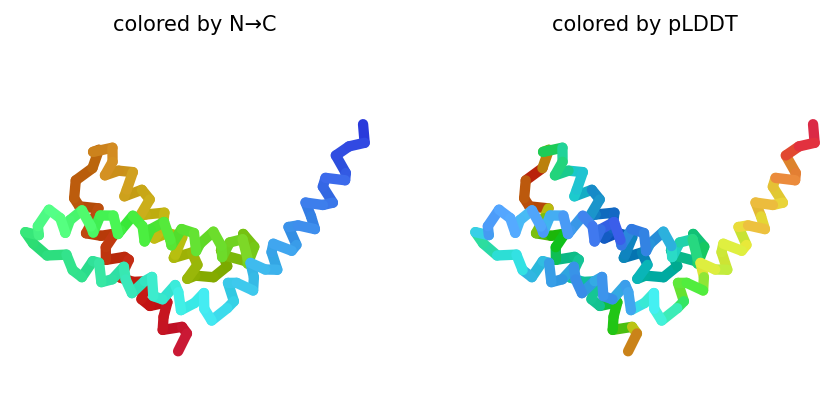

2026-05-01 21:23:39,094 alphafold2_ptm_model_3_seed_000 recycle=0 pLDDT=82.3 pTM=0.689
2026-05-01 21:23:49,635 alphafold2_ptm_model_3_seed_000 recycle=1 pLDDT=82.6 pTM=0.698 tol=0.193
2026-05-01 21:24:00,207 alphafold2_ptm_model_3_seed_000 recycle=2 pLDDT=82.8 pTM=0.705 tol=0.0985
2026-05-01 21:24:10,781 alphafold2_ptm_model_3_seed_000 recycle=3 pLDDT=82.9 pTM=0.708 tol=0.0649
2026-05-01 21:24:10,782 alphafold2_ptm_model_3_seed_000 took 42.1s (3 recycles)


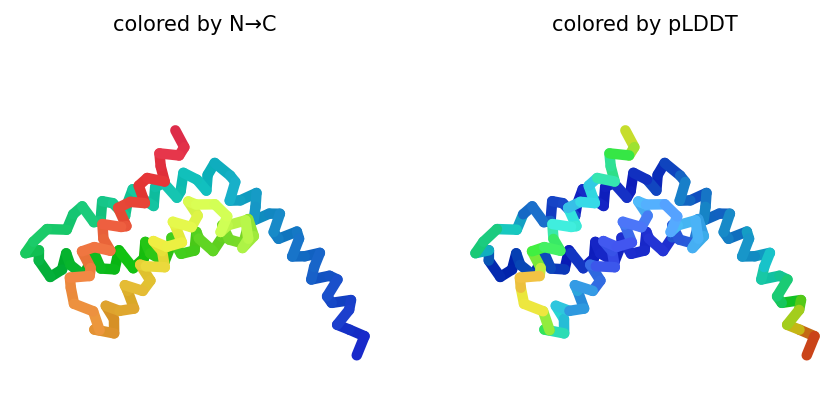

2026-05-01 21:24:21,386 alphafold2_ptm_model_4_seed_000 recycle=0 pLDDT=79.6 pTM=0.649
2026-05-01 21:24:31,786 alphafold2_ptm_model_4_seed_000 recycle=1 pLDDT=78.2 pTM=0.641 tol=0.195
2026-05-01 21:24:42,161 alphafold2_ptm_model_4_seed_000 recycle=2 pLDDT=78.2 pTM=0.645 tol=0.118
2026-05-01 21:24:52,547 alphafold2_ptm_model_4_seed_000 recycle=3 pLDDT=78 pTM=0.643 tol=0.0775
2026-05-01 21:24:52,548 alphafold2_ptm_model_4_seed_000 took 41.7s (3 recycles)


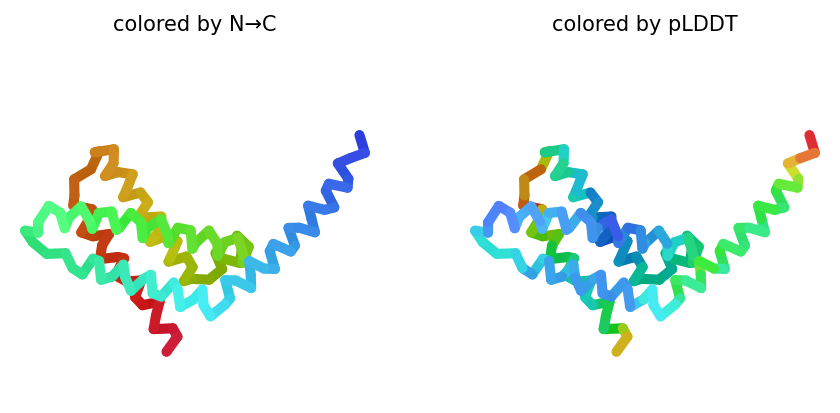

2026-05-01 21:25:03,136 alphafold2_ptm_model_5_seed_000 recycle=0 pLDDT=82.9 pTM=0.71
2026-05-01 21:25:13,569 alphafold2_ptm_model_5_seed_000 recycle=1 pLDDT=82.5 pTM=0.713 tol=0.165
2026-05-01 21:25:24,032 alphafold2_ptm_model_5_seed_000 recycle=2 pLDDT=82.9 pTM=0.719 tol=0.084
2026-05-01 21:25:34,511 alphafold2_ptm_model_5_seed_000 recycle=3 pLDDT=82.6 pTM=0.721 tol=0.0814
2026-05-01 21:25:34,512 alphafold2_ptm_model_5_seed_000 took 41.8s (3 recycles)


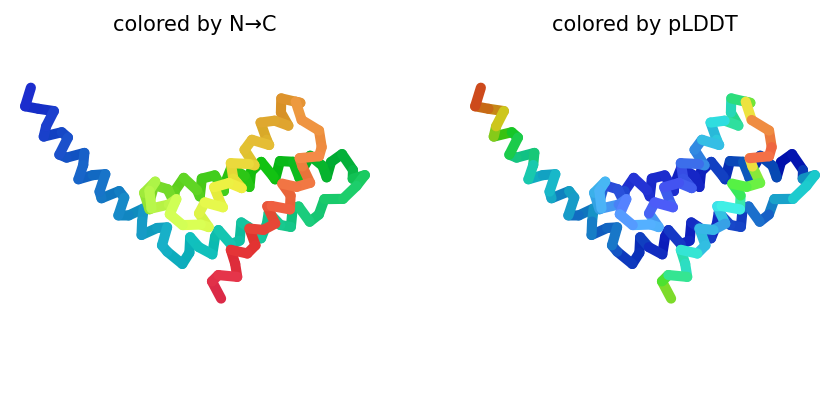

2026-05-01 21:25:34,620 reranking models by 'plddt' metric
2026-05-01 21:25:34,620 rank_001_alphafold2_ptm_model_3_seed_000 pLDDT=82.9 pTM=0.708
2026-05-01 21:25:34,621 rank_002_alphafold2_ptm_model_5_seed_000 pLDDT=82.6 pTM=0.721
2026-05-01 21:25:34,621 rank_003_alphafold2_ptm_model_4_seed_000 pLDDT=78 pTM=0.643
2026-05-01 21:25:34,621 rank_004_alphafold2_ptm_model_2_seed_000 pLDDT=76 pTM=0.661
2026-05-01 21:25:34,621 rank_005_alphafold2_ptm_model_1_seed_000 pLDDT=75.9 pTM=0.639
2026-05-01 21:25:35,805 Done

Final active result for downstream cells: TARGETED-MASKED prediction


0

In [ ]:
#@title Run Prediction
display_images = True #@param {type:"boolean"}
run_vanilla_first = True #@param {type:"boolean"}
run_targeted_masked_prediction = True #@param {type:"boolean"}
#@markdown - Default workflow: run **vanilla first**, then build the targeted-masked A3M, then run the **targeted-masked** prediction.
#@markdown - Turn off `run_vanilla_first` only if the A3M already exists or you only want to rerun the masked prediction.
#@markdown - Turn off `run_targeted_masked_prediction` if you only want the original vanilla ColabFold result.

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

if not run_vanilla_first and not run_targeted_masked_prediction:
  raise ValueError("Nothing selected to run. Enable run_vanilla_first and/or run_targeted_masked_prediction.")

def run_colabfold_prediction(run_label, run_queries_path, run_msa_mode):
  """Run one ColabFold prediction pass and return (results, queries, is_complex, resolved_model_type)."""
  print("\\n" + "="*80)
  print(f"Running {run_label} prediction")
  print("="*80)
  print("queries/MSA input:", run_queries_path)
  print("msa_mode:", run_msa_mode)

  current_queries, current_is_complex = get_queries(run_queries_path)
  current_model_type = set_model_type(current_is_complex, model_type)

  if "multimer" in current_model_type and max_msa is not None:
    current_use_cluster_profile = False
  else:
    current_use_cluster_profile = True

  download_alphafold_params(current_model_type, Path("."))
  current_results = run(
      queries=current_queries,
      result_dir=result_dir,
      use_templates=use_templates,
      custom_template_path=custom_template_path,
      num_relax=num_relax,
      msa_mode=run_msa_mode,
      model_type=current_model_type,
      num_models=5,
      num_recycles=num_recycles,
      relax_max_iterations=relax_max_iterations,
      recycle_early_stop_tolerance=recycle_early_stop_tolerance,
      num_seeds=num_seeds,
      use_dropout=use_dropout,
      model_order=[1,2,3,4,5],
      is_complex=current_is_complex,
      data_dir=Path("."),
      keep_existing_results=False,
      rank_by="auto",
      pair_mode=pair_mode,
      pairing_strategy=pairing_strategy,
      stop_at_score=float(100),
      prediction_callback=prediction_callback,
      dpi=dpi,
      zip_results=False,
      save_all=save_all,
      max_msa=max_msa,
      use_cluster_profile=current_use_cluster_profile,
      input_features_callback=input_features_callback,
      save_recycles=save_recycles,
      user_agent="colabfold/google-colab-main",
      calc_extra_ptm=calc_extra_ptm,
  )
  return current_results, current_queries, current_is_complex, current_model_type

results_vanilla = None
results_targeted_masked = None
results = None

# 1) Optional vanilla run. This is useful because MMseqs2 mode writes the A3M needed for masking.
if run_vanilla_first:
  results_vanilla, queries_vanilla, is_complex_vanilla, model_type_vanilla = run_colabfold_prediction(
      run_label="vanilla",
      run_queries_path=queries_path,
      run_msa_mode=msa_mode,
  )
  results = results_vanilla
  queries = queries_vanilla
  is_complex = is_complex_vanilla
  jobname_prefix = "" if msa_mode != "custom" else ".custom"

# 2) Prepare targeted-masked A3M after vanilla, or use an existing A3M if vanilla was skipped.
if run_targeted_masked_prediction:
  if 'prepare_masked_a3m_if_possible' not in globals():
    raise NameError("prepare_masked_a3m_if_possible() was not defined. Run the Targeted masking controls cell first.")

  if 'has_requested_targeted_masking' in globals() and not has_requested_targeted_masking():
    print("\nNo mutant_ranges or targeted_masking_positions were provided.")
    print("Skipping targeted-masked prediction and keeping the vanilla result active.")
    if results is None:
      raise ValueError("No prediction was run. Enable run_vanilla_first or provide targeted masking positions.")
  else:
    if not os.path.isfile(a3m_file):
      raise FileNotFoundError(
          f"Could not find A3M file: {a3m_file}. "
          "Enable run_vanilla_first, or provide/upload a custom A3M first."
      )

    masking_report = prepare_masked_a3m_if_possible()
    if masking_report is None or not os.path.isfile(masked_a3m_file):
      raise FileNotFoundError(
          "Targeted-masked A3M was not created. Check masking_action, mutant_ranges/targeted_masking_positions, and the A3M path."
      )

    results_targeted_masked, queries_targeted_masked, is_complex_targeted_masked, model_type_targeted_masked = run_colabfold_prediction(
        run_label="targeted-masked A3M",
        run_queries_path=masked_a3m_file,
        run_msa_mode="custom",
    )
    results = results_targeted_masked
    queries = queries_targeted_masked
    is_complex = is_complex_targeted_masked
    jobname_prefix = ".custom"
    print("\nFinal active result for downstream cells: TARGETED-MASKED prediction")
else:
  print("\nTargeted-masked prediction is OFF.")
  if results is not None:
    print("Final active result for downstream cells: VANILLA prediction")
  else:
    print("No active result yet.")

results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")


In [ ]:
# How to display targeted masked residues in py3Dmol
# Options: "sticks_and_spheres", "sticks", "spheres", "none"
targeted_masked_residue_representation = "sticks_and_spheres"

Highlighted targeted-masked positions on chain A: [15, 19, 22, 23, 26, 28, 31, 32, 38, 42, 45, 49, 59, 62, 65, 72, 73, 75, 76, 78, 79, 81, 82, 88, 94, 97, 98, 102, 107, 112, 122, 125, 128, 131, 134, 137]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

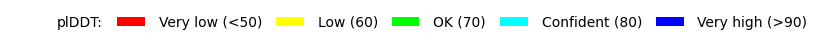

In [ ]:
#@title Display 3D structure {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list

rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}
show_targeted_masked_residues = True #@param {type:"boolean"}
targeted_targeted_masked_residue_representation = "sticks_and_spheres" #@param ["sticks_and_spheres", "spheres", "sticks"] {type:"string"}

tag = results["rank"][0][rank_num - 1]
jobname_prefix = globals().get("jobname_prefix", ".custom" if msa_mode == "custom" else "")
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

if not pdb_file:
  # fallback: look for the requested ranked model regardless of prefix
  fallback = sorted(glob.glob(f"{jobname}/{jobname}*_unrelaxed_{tag}.pdb"))
  if fallback:
    pdb_file = [fallback[0]]
  else:
    raise FileNotFoundError(f"Could not find predicted PDB for tag {tag}. Tried: {pdb_filename}")

def get_masked_positions_for_viewer():
  """Return targeted-masked positions and chain letter for 3D highlighting."""
  report = globals().get("masking_report", None)
  if report and report.get("applied_positions"):
    positions = report.get("applied_positions", [])
    chain = report.get("mask_chain", globals().get("mask_chain", "A"))
    return positions, chain

  # Fallback: use requested ranges directly if a report is not available.
  positions = []
  if "parse_ranges_for_preview" in globals():
    if globals().get("mutant_ranges", ""):
      positions += parse_ranges_for_preview(mutant_ranges)
    if globals().get("targeted_masking_positions", ""):
      positions += parse_ranges_for_preview(targeted_masking_positions)
  return sorted(set(positions)), globals().get("mask_chain", "A")

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color_i in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color_i}})

  if show_targeted_masked_residues:
    masked_positions, masked_chain = get_masked_positions_for_viewer()
    if masked_positions:
      selection = {'resi': [str(x) for x in masked_positions]}
      if masked_chain:
        selection['chain'] = str(masked_chain).strip().upper()[0]
      if targeted_masked_residue_representation in ["sticks_and_spheres", "sticks"]:
        view.addStyle(selection, {'stick': {'color': 'magenta', 'radius': 0.35}})
      if targeted_masked_residue_representation in ["sticks_and_spheres", "spheres"]:
        view.addStyle({'and': [selection, {'atom': 'CA'}]}, {'sphere': {'color': 'magenta', 'radius': 0.75}})
      print(f"Highlighted targeted-masked positions on chain {selection.get('chain', 'all')}: {masked_positions}")
    else:
      print("No targeted-masked positions available to highlight. Add mutant_ranges or targeted_masking_positions, then rerun masking/prediction.")

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
if color == "lDDT":
  plot_plddt_legend().show()



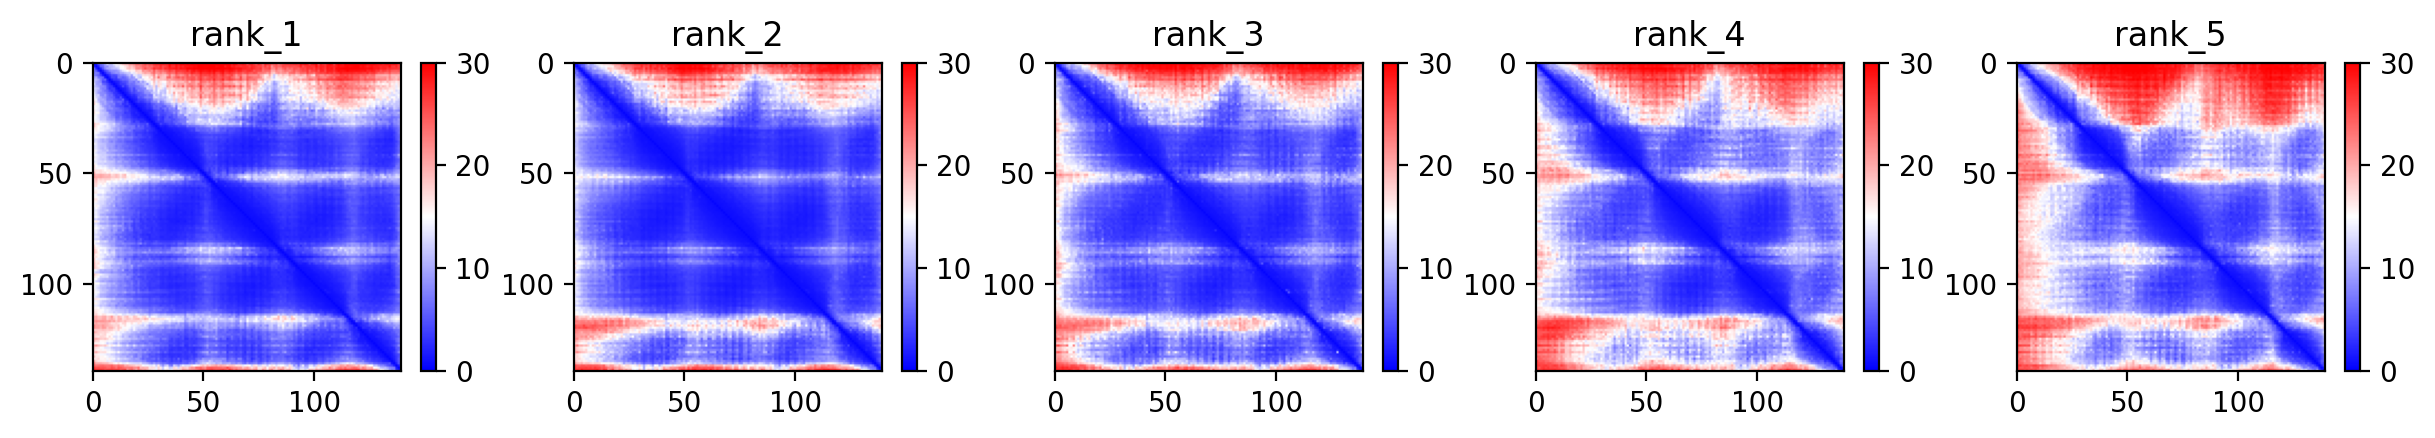
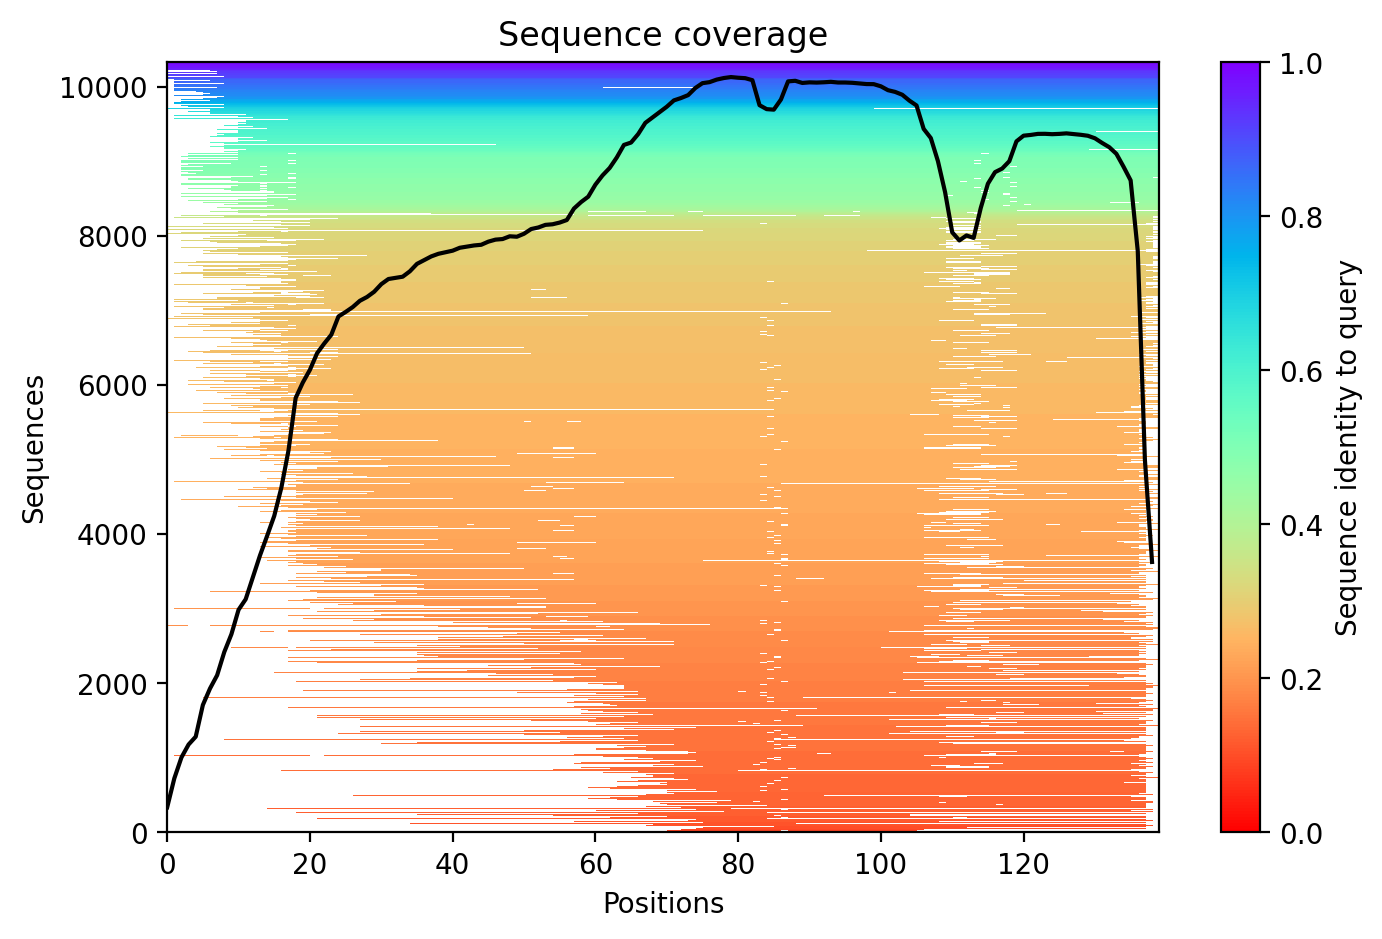
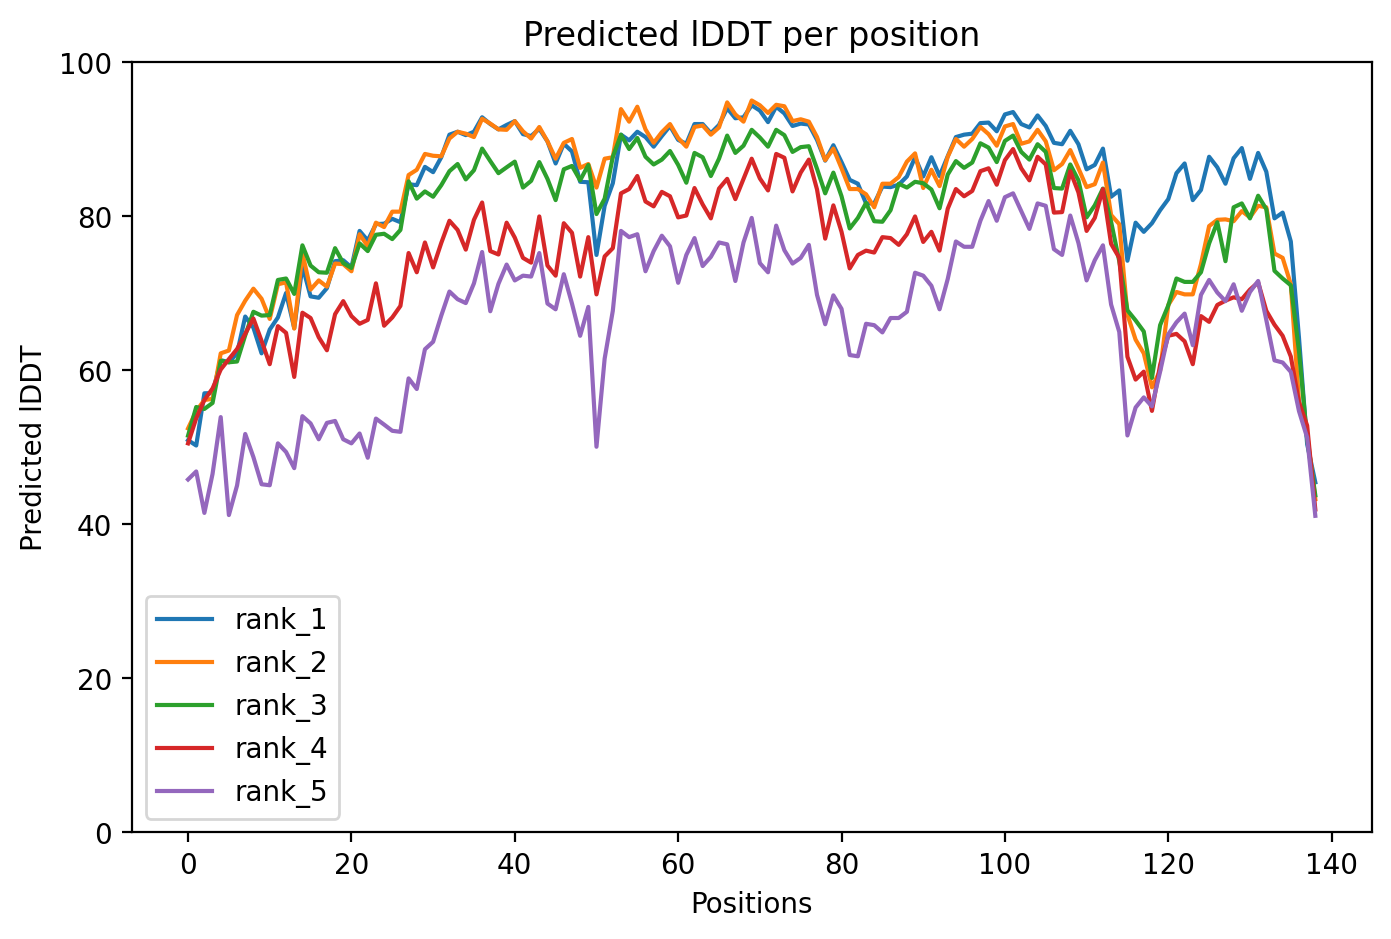

In [ ]:
#@title Plots {run: "auto"}
from IPython.display import display, HTML
import base64, os, glob
from html import escape

def safe_image_to_data_url(filename):
  """Return a base64 image URL if the file exists; otherwise return None."""
  if not filename or not os.path.isfile(filename):
    return None
  ext = filename.split('.')[-1]
  prefix = f'data:image/{ext};base64,'
  with open(filename, 'rb') as f:
    img = f.read()
  return prefix + base64.b64encode(img).decode('utf-8')

def find_plot_file(kind):
  """Find plot files robustly for vanilla and custom/targeted-masked runs."""
  candidates = []
  prefix = globals().get("jobname_prefix", "")
  candidates.append(os.path.join(jobname, f"{jobname}{prefix}_{kind}.png"))
  candidates.append(os.path.join(jobname, f"{jobname}_{kind}.png"))
  candidates.append(os.path.join(jobname, f"{jobname}.custom_{kind}.png"))
  candidates.extend(sorted(glob.glob(os.path.join(jobname, f"*_{kind}.png"))))
  for fn in candidates:
    if os.path.isfile(fn):
      return fn
  return None

pae_file = find_plot_file("pae") or find_plot_file("PAE")
cov_file = find_plot_file("coverage")
plddt_file = find_plot_file("plddt")

pae = safe_image_to_data_url(pae_file)
cov = safe_image_to_data_url(cov_file)
plddt = safe_image_to_data_url(plddt_file)

cards = []
if pae:
  cards.append(f'<div><h3>PAE</h3><img src="{pae}" class="full" /></div>')
if cov:
  cards.append(f'<div><h3>MSA coverage</h3><img src="{cov}" class="half" /></div>')
else:
  cards.append('<div style="padding:0.8em;border:1px solid #ddd;border-radius:8px;margin:0.5em 0;"><b>MSA coverage plot not found.</b><br>This is common for some custom/targeted-masked A3M runs, so the notebook will continue.</div>')
if plddt:
  cards.append(f'<div><h3>pLDDT</h3><img src="{plddt}" class="half" /></div>')
else:
  cards.append('<div style="padding:0.8em;border:1px solid #ddd;border-radius:8px;margin:0.5em 0;"><b>pLDDT plot not found.</b><br>The prediction output files may still be present even if this PNG was not generated.</div>')

display(HTML(f"""
<style>
  img {{
    float:left;
    margin: 0.5em;
  }}
  .full {{
    max-width:100%;
  }}
  .half {{
    max-width:50%;
  }}
  @media (max-width:640px) {{
    .half {{
      max-width:100%;
    }}
  }}
</style>
<div style="max-width:90%; padding:2em;">
  <h1>Plots for {escape(jobname)}</h1>
  {''.join(cards)}
  <div style="clear:both;"></div>
</div>
"""))


In [ ]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive, try disabling your adblocker and run this cell again. If that fails click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

if msa_mode == "custom":
  print("Don't forget to cite your custom MSA generation method.")

files.download(f"{jobname}.result.zip")

if save_to_google_drive == True and drive:
  uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
  uploaded.SetContentFile(f"{jobname}.result.zip")
  uploaded.Upload()
  print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Instructions <a name="Instructions"></a>
For detailed instructions, tips and tricks, see recently published paper at [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5)

**Quick start**
1. Paste your protein sequence(s) in the input field.
2. Press "Runtime" -> "Run all".
3. The pipeline consists of 5 steps. The currently running step is indicated by a circle with a stop sign next to it.

**Result zip file contents**

1. PDB formatted structures sorted by avg. pLDDT and complexes are sorted by pTMscore. (unrelaxed and relaxed if `use_amber` is enabled).
2. Plots of the model quality.
3. Plots of the MSA coverage.
4. Parameter log file.
5. A3M formatted input MSA.
6. A `predicted_aligned_error_v1.json` using [AlphaFold-DB's format](https://alphafold.ebi.ac.uk/faq#faq-7) and a `scores.json` for each model which contains an array (list of lists) for PAE, a list with the average pLDDT and the pTMscore.
7. BibTeX file with citations for all used tools and databases.

At the end of the job a download modal box will pop up with a `jobname.result.zip` file. Additionally, if the `save_to_google_drive` option was selected, the `jobname.result.zip` will be uploaded to your Google Drive.

**MSA generation for complexes**

For the complex prediction we use unpaired and paired MSAs. Unpaired MSA is generated the same way as for the protein structures prediction by searching the UniRef100 and environmental sequences three iterations each.

The paired MSA is generated by searching the UniRef100 database and pairing the best hits sharing the same NCBI taxonomic identifier (=species or sub-species). We only pair sequences if all of the query sequences are present for the respective taxonomic identifier.

**Using a custom MSA as input**

To predict the structure with a custom MSA (A3M formatted): (1) Change the `msa_mode`: to "custom", (2) Wait for an upload box to appear at the end of the "MSA options ..." box. Upload your A3M. The first fasta entry of the A3M must be the query sequence without gaps.

It is also possilbe to provide custom MSAs for complex predictions. Read more about the format [here](https://github.com/sokrypton/ColabFold/issues/76).

As an alternative for MSA generation the [HHblits Toolkit server](https://toolkit.tuebingen.mpg.de/tools/hhblits) can be used. After submitting your query, click "Query Template MSA" -> "Download Full A3M". Download the A3M file and upload it in this notebook.

**PDB100** <a name="pdb100"></a>

As of 23/06/08, we have transitioned from using the PDB70 to a 100% clustered PDB, the PDB100. The construction methodology of PDB100 differs from that of PDB70.

The PDB70 was constructed by running each PDB70 representative sequence through [HHblits](https://github.com/soedinglab/hh-suite) against the [Uniclust30](https://uniclust.mmseqs.com/). On the other hand, the PDB100 is built by searching each PDB100 representative structure with [Foldseek](https://github.com/steineggerlab/foldseek) against the [AlphaFold Database](https://alphafold.ebi.ac.uk).

To maintain compatibility with older Notebook versions and local installations, the generated files and API responses will continue to be named "PDB70", even though we're now using the PDB100.

**Using custom templates** <a name="custom_templates"></a>

To predict the structure with a custom template (PDB or mmCIF formatted): (1) change the `template_mode` to "custom" in the execute cell and (2) wait for an upload box to appear at the end of the "Input Protein" box. Select and upload your templates (multiple choices are possible).

* Templates must follow the four letter PDB naming with lower case letters.

* Templates in mmCIF format must contain `_entity_poly_seq`. An error is thrown if this field is not present. The field `_pdbx_audit_revision_history.revision_date` is automatically generated if it is not present.

* Templates in PDB format are automatically converted to the mmCIF format. `_entity_poly_seq` and `_pdbx_audit_revision_history.revision_date` are automatically generated.

If you encounter problems, please report them to this [issue](https://github.com/sokrypton/ColabFold/issues/177).

**Comparison to the full AlphaFold2 and AlphaFold2 Colab**

This notebook replaces the homology detection and MSA pairing of AlphaFold2 with MMseqs2. For a comparison against the [AlphaFold2 Colab](https://colab.research.google.com/github/deepmind/alphafold/blob/main/notebooks/AlphaFold.ipynb) and the full [AlphaFold2](https://github.com/deepmind/alphafold) system read our [paper](https://www.nature.com/articles/s41592-022-01488-1).

**Troubleshooting**
* Check that the runtime type is set to GPU at "Runtime" -> "Change runtime type".
* Try to restart the session "Runtime" -> "Factory reset runtime".
* Check your input sequence.

**Known issues**
* Google Colab assigns different types of GPUs with varying amount of memory. Some might not have enough memory to predict the structure for a long sequence.
* Your browser can block the pop-up for downloading the result file. You can choose the `save_to_google_drive` option to upload to Google Drive instead or manually download the result file: Click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

**Limitations**
* Computing resources: Our MMseqs2 API can handle ~20-50k requests per day.
* MSAs: MMseqs2 is very precise and sensitive but might find less hits compared to HHblits/HMMer searched against BFD or MGnify.
* We recommend to additionally use the full [AlphaFold2 pipeline](https://github.com/deepmind/alphafold).

**Description of the plots**
*   **Number of sequences per position** - We want to see at least 30 sequences per position, for best performance, ideally 100 sequences.
*   **Predicted lDDT per position** - model confidence (out of 100) at each position. The higher the better.
*   **Predicted Alignment Error** - For homooligomers, this could be a useful metric to assess how confident the model is about the interface. The lower the better.

**Bugs**
- If you encounter any bugs, please report the issue to https://github.com/sokrypton/ColabFold/issues

**License**

The source code of ColabFold is licensed under [MIT](https://raw.githubusercontent.com/sokrypton/ColabFold/main/LICENSE). Additionally, this notebook uses the AlphaFold2 source code and its parameters licensed under [Apache 2.0](https://raw.githubusercontent.com/deepmind/alphafold/main/LICENSE) and [CC BY 4.0](https://creativecommons.org/licenses/by-sa/4.0/) respectively. Read more about the AlphaFold license [here](https://github.com/deepmind/alphafold).

**Acknowledgments**
- We thank the AlphaFold team for developing an excellent model and open sourcing the software.

- [KOBIC](https://kobic.re.kr) and [Söding Lab](https://www.mpinat.mpg.de/soeding) for providing the computational resources for the MMseqs2 MSA server.

- Richard Evans for helping to benchmark the ColabFold's Alphafold-multimer support.

- [David Koes](https://github.com/dkoes) for his awesome [py3Dmol](https://3dmol.csb.pitt.edu/) plugin, without whom these notebooks would be quite boring!

- Do-Yoon Kim for creating the ColabFold logo.

- A colab by Sergey Ovchinnikov ([@sokrypton](https://twitter.com/sokrypton)), Milot Mirdita ([@milot_mirdita](https://twitter.com/milot_mirdita)) and Martin Steinegger ([@thesteinegger](https://twitter.com/thesteinegger)).
